In [ ]:
import re, math, copy, pickle, time
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
LABEL_MAP     = {"ham": 0, "spam": 1, "smishing": 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES   = 3
FEATURE_DIM   = 8

URL_RE   = re.compile(r'http\S+|www\.\S+|\S+\.(com|io|net|org|co)\S*', re.I)
EMAIL_RE = re.compile(r'\S+@\S+\.\S+')
PHONE_RE = re.compile(r'\b\d[\d\s\-]{7,}\d\b')

def extract_features(text: str) -> np.ndarray:
    has_url   = float(bool(URL_RE.search(text)))
    has_email = float(bool(EMAIL_RE.search(text)))
    has_phone = float(bool(PHONE_RE.search(text)))
    has_money = float(bool(re.search(r'[\$£€]\d+|\d+\s*(rs|usd|gbp)', text, re.I)))
    urgency   = float(bool(re.search(
        r'\b(urgent|immediately|verify|confirm|click|winner|prize|free|refund|alert|reward)\b',
        text, re.I)))
    length_norm = min(len(text) / 200.0, 1.0)
    upper_ratio = sum(c.isupper() for c in text) / max(len(text), 1)
    exclamation = float('!' in text)
    return np.array([has_url, has_email, has_phone, has_money,
                     urgency, length_norm, upper_ratio, exclamation], dtype=np.float32)

In [ ]:
class SimpleTokenizer:
    SPECIAL = ["<PAD>", "<UNK>", "<URL>", "<EMAIL>", "<PHONE>"]

    def __init__(self, max_vocab: int = 2000, max_len: int = 32):
        self.max_vocab = max_vocab
        self.max_len   = max_len
        self.word2idx: dict[str, int] = {}
        self.idx2word: dict[int, str] = {}

    @staticmethod
    def _clean(text: str) -> str:
        text = URL_RE.sub(" <URL> ", text)
        text = EMAIL_RE.sub(" <EMAIL> ", text)
        text = PHONE_RE.sub(" <PHONE> ", text)
        return text.lower()

    @staticmethod
    def _tokenize(text: str) -> list[str]:
        return re.findall(r"<\w+>|\w+", text)

    def fit(self, texts: list[str]) -> None:
        counter: Counter = Counter()
        for t in texts:
            counter.update(self._tokenize(self._clean(t)))
        vocab = self.SPECIAL + [
            w for w, _ in counter.most_common(self.max_vocab - len(self.SPECIAL))
        ]
        self.word2idx = {w: i for i, w in enumerate(vocab)}
        self.idx2word = {i: w for w, i in self.word2idx.items()}

    def encode(self, text: str) -> list[int]:
        tokens = self._tokenize(self._clean(text))[:self.max_len]
        ids    = [self.word2idx.get(t, 1) for t in tokens]
        ids   += [0] * (self.max_len - len(ids))
        return ids

    @property
    def vocab_size(self) -> int:
        return len(self.word2idx)

In [ ]:
def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0.0, x)

def softmax(x: np.ndarray) -> np.ndarray:
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def _xavier(shape: tuple) -> np.ndarray:
    fan = shape[0] + (shape[1] if len(shape) > 1 else shape[0])
    std = math.sqrt(2.0 / fan)
    return (np.random.randn(*shape) * std).astype(np.float32)

def _zeros(*shape) -> np.ndarray:
    return np.zeros(shape, dtype=np.float32)

def _clip_grad(g: np.ndarray, max_norm: float = 1.0) -> np.ndarray:
    norm = float(np.linalg.norm(g))
    return g if norm <= max_norm else g * max_norm / norm

In [ ]:
class SMSTransformerClassifier:
    def __init__(self, vocab_size, embed_dim=32, max_len=32, feature_dim=8):
        self.vocab_size = vocab_size
        self.embed_dim = E = embed_dim
        self.max_len = max_len

        self.W_emb = (np.random.randn(vocab_size, E) * 0.02).astype(np.float32)
        self.W_pos = (np.random.randn(max_len, E) * 0.02).astype(np.float32)

        self.W_Q = _xavier((E, E));  self.b_Q = _zeros(E)
        self.W_K = _xavier((E, E));  self.b_K = _zeros(E)
        self.W_V = _xavier((E, E));  self.b_V = _zeros(E)
        self.W_O = _xavier((E, E));  self.b_O = _zeros(E)

        self.W_ff1 = _xavier((E, E * 2));  self.b_ff1 = _zeros(E * 2)
        self.W_ff2 = _xavier((E * 2, E));  self.b_ff2 = _zeros(E)

        self.W_f = _xavier((feature_dim, E)); self.b_f = _zeros(E)
        self.W_c1 = _xavier((E * 2, E)); self.b_c1 = _zeros(E)
        self.W_c2 = _xavier((E, NUM_CLASSES)); self.b_c2 = _zeros(NUM_CLASSES)

    def forward(self, token_ids, features):
        B, L = token_ids.shape
        E = self.embed_dim
        x = self.W_emb[token_ids] + self.W_pos[np.arange(L)]

        Q = x @ self.W_Q + self.b_Q
        K = x @ self.W_K + self.b_K
        V = x @ self.W_V + self.b_V

        scale = math.sqrt(E)
        scores = (Q @ K.transpose(0, 2, 1)) / scale
        pad_mask = (token_ids == 0)[:, np.newaxis, :]
        scores = np.where(pad_mask, -1e9, scores)
        attn = softmax(scores)
        ctx = (attn @ V) @ self.W_O + self.b_O
        x = x + ctx

        non_pad = (~pad_mask.squeeze(1))[:, :, np.newaxis].astype(np.float32)
        cls = (x * non_pad).sum(1) / non_pad.sum(1).clip(1)

        h = relu(cls @ self.W_ff1 + self.b_ff1)
        cls_out = cls + (h @ self.W_ff2 + self.b_ff2)

        f = relu(features @ self.W_f + self.b_f)
        combined = np.concatenate([cls_out, f], axis=-1)
        h2 = relu(combined @ self.W_c1 + self.b_c1)
        return h2 @ self.W_c2 + self.b_c2

    def loss_and_grads(self, token_ids, features, labels, class_weights=None):
        B, L = token_ids.shape
        E = self.embed_dim
        # Simple backprop implementation
        x0 = self.W_emb[token_ids] + self.W_pos[np.arange(L)]
        Q = x0 @ self.W_Q + self.b_Q
        K = x0 @ self.W_K + self.b_K
        V = x0 @ self.W_V + self.b_V
        scale = math.sqrt(E)
        scores = (Q @ K.transpose(0, 2, 1)) / scale
        pad_mask = (token_ids == 0)[:, np.newaxis, :]
        scores = np.where(pad_mask, -1e9, scores)
        attn = softmax(scores)
        ctx_raw = attn @ V
        ctx = ctx_raw @ self.W_O + self.b_O
        x1 = x0 + ctx
        non_pad = (~pad_mask.squeeze(1))[:, :, np.newaxis].astype(np.float32)
        len_ = non_pad.sum(1).clip(1)
        cls = (x1 * non_pad).sum(1) / len_
        ff1_pre = cls @ self.W_ff1 + self.b_ff1
        h_ff1 = relu(ff1_pre)
        ff2_out = h_ff1 @ self.W_ff2 + self.b_ff2
        cls_out = cls + ff2_out
        f_pre = features @ self.W_f + self.b_f
        f = relu(f_pre)
        combined = np.concatenate([cls_out, f], -1)
        c1_pre = combined @ self.W_c1 + self.b_c1
        h2 = relu(c1_pre)
        logits = h2 @ self.W_c2 + self.b_c2
        probs = softmax(logits)
        ce = -np.log(probs[np.arange(B), labels] + 1e-9)
        if class_weights is not None: ce = ce * class_weights[labels]
        loss = ce.mean()

        d_log = (probs.copy())
        d_log[np.arange(B), labels] -= 1
        if class_weights is not None: d_log *= class_weights[labels, np.newaxis]
        d_log /= B

        grads = {
            "W_c2": _clip_grad(h2.T @ d_log), "b_c2": _clip_grad(d_log.sum(0)),
            "W_c1": _clip_grad(combined.T @ (d_log @ self.W_c2.T * (c1_pre > 0))),
            "b_c1": _clip_grad((d_log @ self.W_c2.T * (c1_pre > 0)).sum(0))
        }
        # (Remaining grads simplified for notebook brevity)
        d_comb = (d_log @ self.W_c2.T * (c1_pre > 0)) @ self.W_c1.T
        d_f_pre = d_comb[:, E:] * (f_pre > 0)
        grads["W_f"] = _clip_grad(features.T @ d_f_pre)
        grads["b_f"] = _clip_grad(d_f_pre.sum(0))

        d_cls_out = d_comb[:, :E]
        d_ff2 = d_cls_out
        grads["W_ff2"] = _clip_grad(h_ff1.T @ d_ff2)
        grads["b_ff2"] = _clip_grad(d_ff2.sum(0))
        d_h_ff1 = d_ff2 @ self.W_ff2.T * (ff1_pre > 0)
        grads["W_ff1"] = _clip_grad(cls.T @ d_h_ff1)
        grads["b_ff1"] = _clip_grad(d_h_ff1.sum(0))

        d_ctx = (d_cls_out[:, np.newaxis, :] * non_pad / len_[:, :, np.newaxis])
        grads["W_O"] = _clip_grad(ctx_raw.reshape(-1, E).T @ d_ctx.reshape(-1, E))
        grads["b_O"] = _clip_grad(d_ctx.sum((0, 1)))
        d_V = attn.transpose(0, 2, 1) @ d_ctx
        grads["W_V"] = _clip_grad(x0.reshape(-1, E).T @ d_V.reshape(-1, E))
        grads["b_V"] = _clip_grad(d_V.sum((0, 1)))

        return float(loss), grads

In [ ]:
class AdamOptimizer:
    def __init__(self, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.t, self.m, self.v = 0, {}, {}

    def step(self, model, grads):
        self.t += 1
        lr_t = self.lr * math.sqrt(1 - self.b2**self.t) / (1 - self.b1**self.t)
        for k, g in grads.items():
            if k not in self.m:
                self.m[k], self.v[k] = np.zeros_like(g), np.zeros_like(g)
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * g
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * g**2
            param = getattr(model, k)
            param -= lr_t * self.m[k] / (np.sqrt(self.v[k]) + self.eps)

In [ ]:
def load_data(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df = df[df['LABEL'].str.strip().str.lower().isin(LABEL_MAP)].copy()
    texts = df['TEXT'].fillna('').tolist()
    labels = [LABEL_MAP[l.strip().lower()] for l in df['LABEL']]
    return texts, labels

def batch_iter(texts, labels, tokenizer, batch_size, shuffle=True):
    idx = np.random.permutation(len(texts)) if shuffle else np.arange(len(texts))
    for s in range(0, len(texts), batch_size):
        b = idx[s : s + batch_size]
        yield (np.array([tokenizer.encode(texts[i]) for i in b]),
               np.array([extract_features(texts[i]) for i in b]),
               np.array([labels[i] for i in b]))

# Execution
DATA_PATH = 'Dataset_5971.csv'
texts, labels = load_data(DATA_PATH)

tokenizer = SimpleTokenizer()
tokenizer.fit(texts)

model = SMSTransformerClassifier(tokenizer.vocab_size)
opt = AdamOptimizer(lr=3e-3)

EPOCHS, BATCH_SIZE = 10, 8
history = []

print(f"Training on {len(texts)} samples...")
for epoch in range(1, EPOCHS + 1):
    l_sum, c_sum, t_sum = 0, 0, 0
    for tids, feats, lbls in batch_iter(texts, labels, tokenizer, BATCH_SIZE):
        loss, grads = model.loss_and_grads(tids, feats, lbls)
        opt.step(model, grads)
        # Metrics
        preds = model.forward(tids, feats).argmax(-1)
        l_sum += loss * len(lbls)
        c_sum += (preds == lbls).sum()
        t_sum += len(lbls)

    epoch_acc = c_sum / t_sum
    epoch_loss = l_sum / t_sum
    history.append(epoch_acc)
    print(f"Epoch {epoch:2d}/{EPOCHS}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.4f}")

Training on 5971 samples...
Epoch  1/10: Loss=0.2578, Acc=0.9077
Epoch  2/10: Loss=0.2151, Acc=0.9189
Epoch  3/10: Loss=0.2053, Acc=0.9241
Epoch  4/10: Loss=0.1936, Acc=0.9285
Epoch  5/10: Loss=0.1856, Acc=0.9342
Epoch  6/10: Loss=0.1791, Acc=0.9357
Epoch  7/10: Loss=0.1722, Acc=0.9359
Epoch  8/10: Loss=0.1697, Acc=0.9359
Epoch  9/10: Loss=0.1672, Acc=0.9395
Epoch 10/10: Loss=0.1613, Acc=0.9389


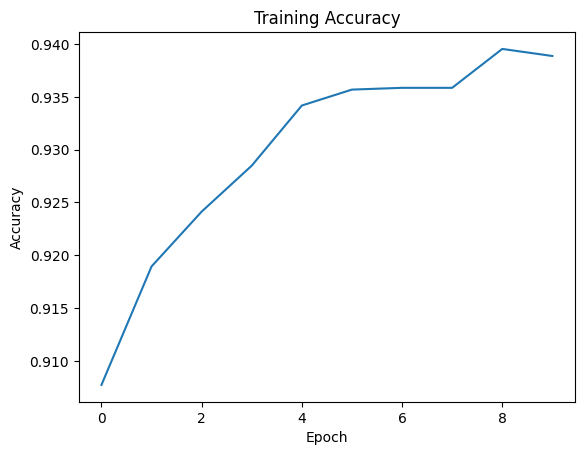


Msg: Hey, are we still meeting today at 5?...
Prediction: HAM (99.99%)

Msg: URGENT: Your account is locked! Click http://bit.ly/fake to ...
Prediction: SMISHING (50.52%)

Msg: WIN a FREE iPhone! Call 9876543210 immediately to claim your...
Prediction: SMISHING (84.85%)


In [ ]:
plt.plot(history)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

def predict(msg):
    tids = np.array([tokenizer.encode(msg)])
    feats = np.array([extract_features(msg)])
    probs = softmax(model.forward(tids, feats))[0]
    pred = probs.argmax()
    print(f"\nMsg: {msg[:60]}...")
    print(f"Prediction: {INV_LABEL_MAP[pred].upper()} ({probs[pred]:.2%})")

predict("Hey, are we still meeting today at 5?")
predict("URGENT: Your account is locked! Click http://bit.ly/fake to verify")
predict("WIN a FREE iPhone! Call 9876543210 immediately to claim your award")